# Processing of RO-Crate for publishing
This notebook will read and RO-Crate file from galaxy, extract the provenance information as PROV-O in JSON-LD and save it into a new version of the RO-Crate.

1. read galaxy ro-crate
2. read the workflow file to get the prospective provenance
3. read the workflow run to get the retrospective provenance
4. merge the provenances into a PROV-O graph
5. save the PROV-O graph in the RO-Crate
6. get a publishable package consisting of RO-Crate + context (a JSON-LD file). The context metadata as JSON-LD is intended to facilitate discovery and interoperability
7. publish package to Invenio RDM (Zenodo if possible)


In [1]:
import zipfile
from pathlib import Path
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, XSD, DCTERMS
import json

# library to support visualisation of graphs
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph

# pyvis used to display the graphs
from pyvis.network import Network


# Namespaces
PROV = Namespace("http://www.w3.org/ns/prov#")
SCHEMA = Namespace("http://schema.org/")
SKOS = Namespace("http://www.w3.org/2004/02/skos/core#")
PPLAN = Namespace("https://vocab.linkeddata.es/p-plan#")

file_formats = {"txt":"text/plain", "cif": "chemical/x-cif",
                "png":"image/png", "prj": "application/vnd.demeter.athena",
                "sp":"text/csv", "gds":"text/csv", "feffit":"text/plain", 
                "feff":"text/csv", "zip":"application/zip",
                "inp":"chemical/x-feff-input"}

# read file from zipped RO-Crate file
def get_file_from_rocratezip(zip_file, file_name):
    roc_zip_file = zipfile.ZipFile(zip_file)
    return roc_zip_file.open(file_name)
    
# Read the zipped crate and get main metadata file
def load_rocrate_metadata(crate_file):
    roc_zip_file = zipfile.ZipFile(crate_file)
    f = get_file_from_rocratezip(crate_file, "ro-crate-metadata.json")
    crate = json.load(f)
    return crate["@graph"]

#Return all JSON-LD entities of a given @type.
def find_entities(graph, type_name):
    return [e for e in graph if type_name in e.get("@type", [])]

#Convert RO-Crate IDs to URIs.
def to_uri(crate_base, entity_id):
    return URIRef(crate_base + entity_id)

#Convert json-ld crate to turtle
def crate_to_turtle(crate_path):
    g = Graph()
    roc_zip_file = zipfile.ZipFile(crate_path)
    f = roc_zip_file.open("ro-crate-metadata.json")
    g.parse(f,format="json-ld")
    out_ttl="ro-crate-metadata.ttl"
    g.serialize(destination=out_ttl, format="turtle")

# get galaxy workflow file from RO-Crate
def get_workflow_json(ro_crate_zip):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_files = find_entities(graph, "File")
    workflow_file = ""
    for a in roc_files:
        if a['@id'][-3:] == ".ga" :
            workflow_file = a['@id']
            break    
    f = get_file_from_rocratezip(ro_crate_zip, workflow_file)
    wf_ga_json = json.load(f)
    return wf_ga_json

# get txt containing entities RO-Crate metadata:
# invocation, datasets, etc
def get_roc_json_part(ro_crate_zip, file_name):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_file = ""
    roc_all_files = find_entities(graph, "File")
    for a in roc_all_files:
        if file_name in a['@id']:
            roc_file = a['@id']
            break
    f = get_file_from_rocratezip(ro_crate_zip, roc_file) 
    file_json = json.load(f)
    return file_json

# data sets are mapped to history objects
def get_mapped_ds(datasets_json, history_mapping):
    ds_id = ""
    for a_ds in datasets_json:
        if 'copied_from_history_dataset_association_id_chain' in a_ds:
            for an_id in a_ds['copied_from_history_dataset_association_id_chain']:
                if an_id == history_mapping:
                    # "History item: {an_id}, Mapped to dataset: {a_ds['encoded_id']}"
                    ds_id = a_ds['encoded_id']
                    break
    return ds_id

# link ds generator to corresponding wf step
def get_wf_step(ds_uri, a_graph):
    ret_val = None
    for s, p, o in a_graph.triples((None, PROV.used, ds_uri)):
        for s1, p1, o1 in a_graph.triples((s, PPLAN.correspondsToStep, None)):
            for s2, p2, o2 in a_graph.triples((o1, PPLAN.isPrecededBy, None)):
                ret_val = o2
                break
    return ret_val

# correct association of sw agents to actions instead of steps
def redirect_software_agents(a_graph):
    to_remove = set()
    to_add = set()
    
    for an_agent in a_graph.subjects(RDF.type, PROV.SoftwareAgent):
        for step in a_graph.subjects(PROV.wasAssociatedWith, an_agent):
            if (step, RDF.type, PPLAN.Step) not in a_graph:
                continue
    
            for prov_activity in a_graph.subjects(PPLAN.correspondsToStep, step):
                to_remove.add((step, PROV.wasAssociatedWith, an_agent))
                to_add.add((prov_activity, PROV.wasAssociatedWith, an_agent))
    
                for used in a_graph.objects(prov_activity, PROV.used):
                    to_add.add((used, PROV.wasAttributedTo, an_agent))
    
                for gen in a_graph.subjects(PROV.wasGeneratedBy, prov_activity):
                    to_add.add((gen, PROV.wasAttributedTo, an_agent))
        
    for triple in to_remove:
        a_graph.remove(triple)
    
    for triple in to_add:
        a_graph.add(triple)

# add custom labels to activities
def custom_labels(a_graph):
    for an_activity in a_graph.subjects(RDF.type, PROV.Activity):
        #print(f"Activity {an_activity}")
        for an_agent in a_graph.objects(an_activity, PROV.wasAssociatedWith):
            #print(f"Activity {an_activity} associated with {an_agent}")
            for agent_label in a_graph.objects(an_agent, RDFS.label):
                #print(f"Agent label: {agent_label}")
                d_label = str(agent_label)
                pref_label = ""
                if d_label == "larch_athena":
                    pref_label = "process and normalise XAS"
                elif d_label == "larch_artemis":
                    pref_label = "FEFF fit of XAS"
                elif d_label == "larch_select_paths":
                    pref_label = "select FEFF paths"
                elif d_label == "larch_feff":
                    pref_label = "calculate FEFF paths from crystal"
                elif d_label == "DATA_FETCH":
                    pref_label = "fetch data from history"
            if pref_label != "":
                a_graph.add((an_activity, SKOS.prefLabel, Literal(pref_label)))

    
# extract steps from wf and invocation files to create prov plan
def extract_prov_json(crate_path,output_file="galaxy_run_prov.ttl"):
    workflow_file = ""
    invocation_file = "" 

    # Load workflow (prospective provenance)
    wf = get_workflow_json(crate_path)
    steps = wf.get("steps", {})

    # Load invocation (retrospective provenance)
    inv = get_roc_json_part(crate_path,"invocation_attrs.txt")
    inv_steps = inv[0].get("steps", {})

    # Load dataset attributes (encoding, names, ) 
    # to gather dataset attributes
    ds_attributes = get_roc_json_part(crate_path,"datasets_attrs.txt")

    # Load job attributes
    # gather input links
    invoked_jobs = get_roc_json_part(crate_path,"jobs_attrs.txt")
    
    g = Graph()
    g.bind("prov", PROV)
    g.bind("schema", SCHEMA)
    g.bind("skos",SKOS)
    g.bind("p-plan", PPLAN)

    base = "/"

    # --- 1. Workflow definition as prov:Plan ---
    wf_uri = URIRef(base + "workflow")
    g.add((wf_uri, RDF.type, PPLAN.Plan))
    g.add((wf_uri, RDFS.label, Literal(wf.get("name", "Galaxy Workflow"))))

    # --- 2. Prospective provenance: workflow steps ---
    for step_id, step in steps.items():
        step_uri = URIRef(base + f"step/{step_id}")
        g.add((step_uri, RDF.type, PPLAN.Step))
        step_label = step.get("label") or step.get("tool_id")
        g.add((step_uri, RDFS.label, Literal(step_label)))

        # Link step to workflow plan
        g.add(( step_uri, PPLAN.isStepOfPlan, wf_uri))

        # Prospective inputs
        for inp in step.get("input_connections", {}).values():
            if isinstance(inp, dict) and "id" in inp:
                src = URIRef(base + f"step/{inp['id']}")
                g.add((step_uri, PPLAN.isPrecededBy, src))

        # Tool as SoftwareAgent (prospective) 
        tool_id = step.get("tool_id")
        if tool_id:
            tool_uri = URIRef(base+f"{tool_id}")
            tool_label = tool_id.split("/")[-2]
            tool_version = tool_id.split("/")[-1]
            g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
            g.add((tool_uri, RDFS.label, Literal(tool_label)))
            g.add((step_uri, PROV.wasAssociatedWith, tool_uri)) # need to associate to activity not step
            #g.add((tool_uri, SKOS.prefLabel, Literal(tool_label)))
            g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
            
    # --- 3. Retrospective provenance: actual execution ---
    for inv_step in inv_steps:
        job = inv_step.get("job")
        
        if not job:
            continue
        step_index = f"{inv_step['order_index']}"
        job_id = job['encoded_id']
        
        act_uri = URIRef(base + f"run/{job_id}")
        g.add((act_uri, RDF.type, PROV.Activity))
        g.add((act_uri, RDFS.label, Literal(f"Execution of step {step_index}")))
    
        # Link execution to prospective step
        step_uri = URIRef(base + f"step/{step_index}")
        g.add((act_uri, PPLAN.correspondsToStep, step_uri))
    
        # Inputs
        for inp_name, dataset in inv_step.get("inputs", {}).items():
            ent_uri = URIRef(base + f"dataset/{dataset['id']}")
            g.add((ent_uri, RDF.type, PROV.Entity))
            g.add((act_uri, PROV.used, ent_uri))      
        
        # Outputs
        step_outputs = inv_step.get("outputs")
        for an_output in step_outputs:
            out_name = an_output['output_name']
            dataset = an_output['dataset']
            ent_uri = URIRef(base + f"dataset/{dataset['encoded_id']}")
            g.add((ent_uri, RDF.type, PROV.Entity))
            g.add((ent_uri, PROV.wasGeneratedBy, act_uri))
            g.add((ent_uri, RDFS.label, Literal(out_name)))

    # Add datset attributes
    for a_ds in ds_attributes:
        ent_uri = (URIRef(base + f"dataset/{a_ds['encoded_id']}"))
        format_str =  file_formats[a_ds['extension']]

        g.add((ent_uri, RDF.type, PROV.Entity)) # duplicated only used for WF_inputs which are not in invocation
        g.add((ent_uri, DCTERMS.format, Literal(format_str)))
        g.add((ent_uri, DCTERMS.description, Literal(a_ds['info'])))
        g.add((ent_uri, SCHEMA.name, Literal(a_ds['file_name'])))
        g.add((ent_uri, SKOS.prefLabel, Literal(a_ds['name']) ))

    # Add the missing links to inputs
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        # link all used datasets to activites
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((job_uri, PROV.used, ds_uri))
                
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        if not (job_uri, RDF.type, PROV.Activity) in g:
            tool_label = a_job['tool_id'].lstrip("_").rstrip("_")
            tool_version = a_job['tool_version']
            tool_uri = URIRef(str(a_job['command_line'].split(' ')[1].strip("'")))
            g.add((job_uri, RDF.type, PROV.Activity))
            g.add((job_uri, RDFS.label, Literal(tool_label)))
            g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
            g.add((tool_uri, RDFS.label, Literal(tool_label)))
            g.add((job_uri, PROV.wasAssociatedWith, tool_uri))
            g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
            
            for a_mapping in a_job['output_dataset_mapping']:
                for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
                    a_ds_id = get_mapped_ds(ds_attributes, a_mapping_id)
                    ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                    g.add((ds_uri, PROV.wasGeneratedBy, job_uri))
                    g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                    # link to associated plan activity
                    step_uri = get_wf_step(ds_uri, g)
                    if step_uri != None:
                        g.add((job_uri, PPLAN.correspondsToStep, step_uri))

    # relocate associations to SoftwareAgents 
    redirect_software_agents(g)
    # Assing human readable labels to activities
    custom_labels(g)
    
    # --- Save ---
    g.serialize(destination=output_file, format="turtle")

    context = {
        "@vocab": "http://www.w3.org/ns/prov#",
        "prov": "http://www.w3.org/ns/prov#",
        "p-plan": "https://vocab.linkeddata.es/p-plan#",
        "schema": "http://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "xsd": "http://www.w3.org/2001/XMLSchema#",
        "dcterms": "http://purl.org/dc/terms/"
    }

    g.serialize(destination=output_file+".json", format="json-ld", 
                context=context, auto_compact=True, indent=2)

    return g
        

input_folder = "./input"
file_name = "FeS2-Analysis.rocrate.zip"

file_path = Path(input_folder,file_name)

if file_path.exists():
    print(f"Working with {str(file_path)}")
    roc_zip_file = zipfile.ZipFile(file_path)

    ro_crate_contents = roc_zip_file.namelist()

    f = roc_zip_file.open("ro-crate-metadata.json")
    content = f.read()

crate_to_turtle(file_path)

roc_graph = extract_prov_json(file_path)

Working with input\FeS2-Analysis.rocrate.zip


In [2]:
nx_graph = rdflib_to_networkx_graph(roc_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 105 nodes and 181 edges loaded successfully
nx.html


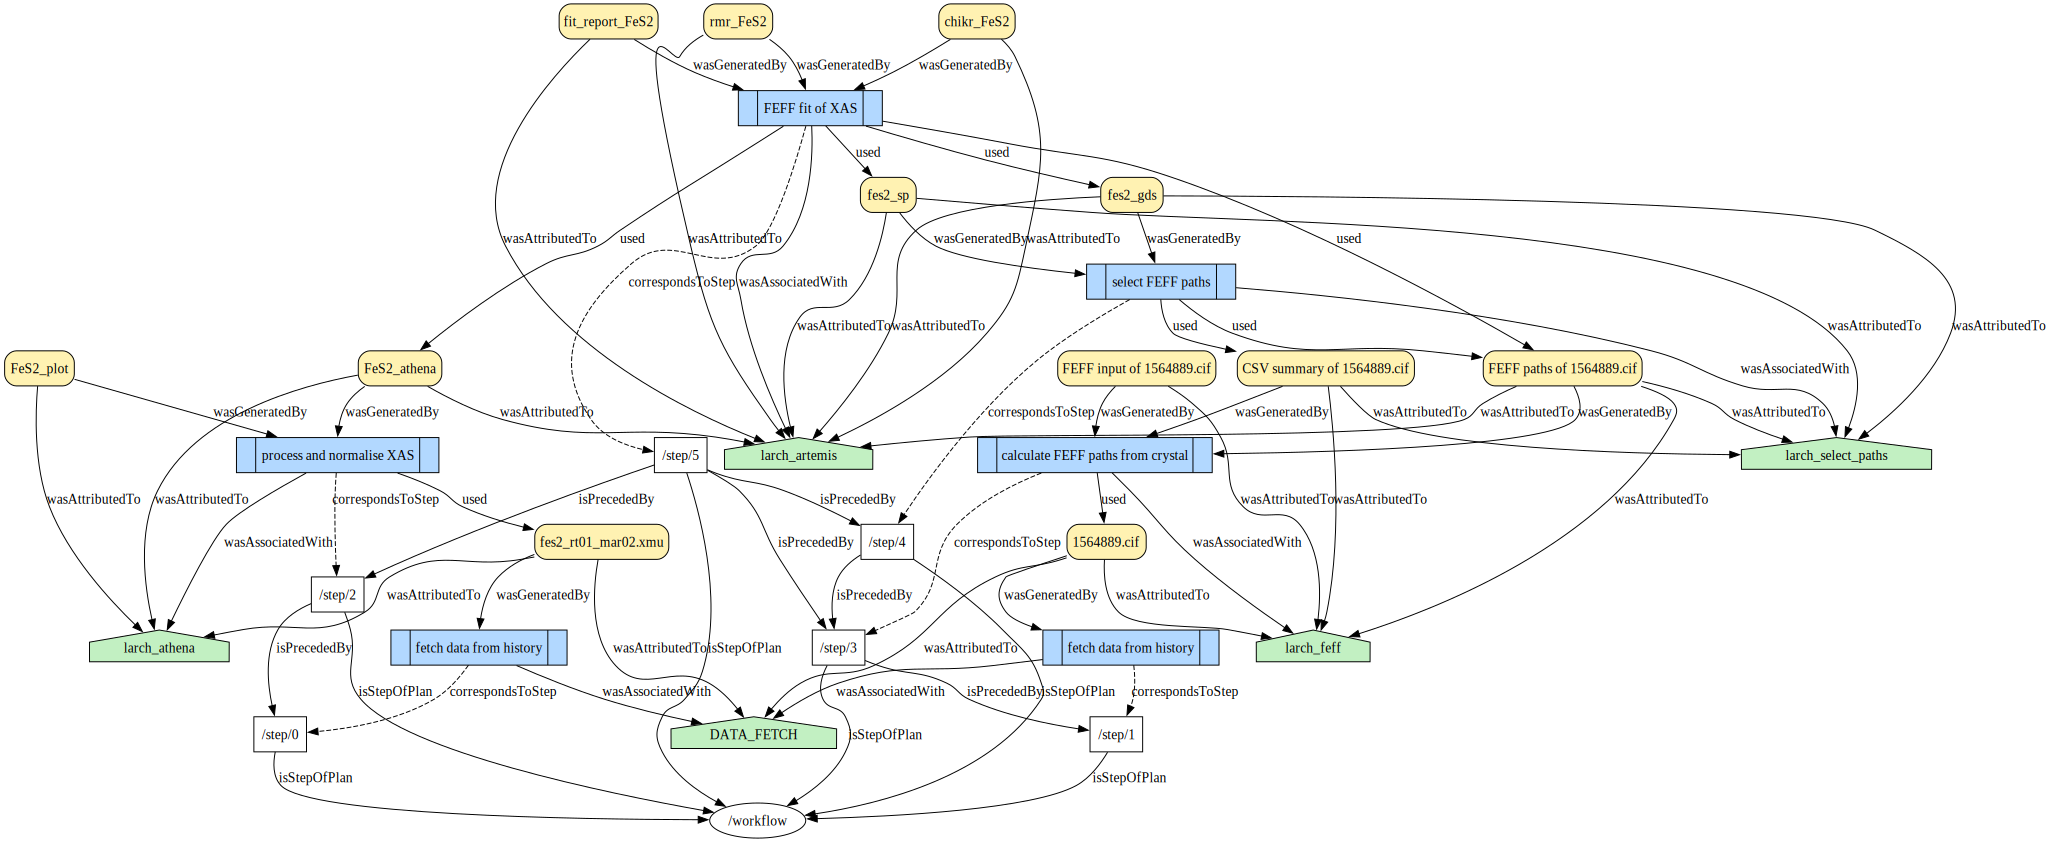

In [3]:
from rdflib import Graph, Namespace, RDF
from graphviz import Digraph
from IPython.display import display
import copy

import os

def get_a_label(graph_thing, a_subject):
    # Try SKOS prefLabel
    for a_label in graph_thing.objects(a_subject, SKOS.prefLabel):
        return str(a_label)

    # Try RDFS label
    for a_label in graph_thing.objects(a_subject, RDFS.label):
        return str(a_label)
        
    return ""

def draw_pplan_only(prov_graph):
    dot = Digraph("prov")

    search_graph = copy.deepcopy(prov_graph)

    for s, p, o in prov_graph:
        node_str = get_a_label(search_graph, s)
        if (s, RDF.type, PPLAN.Step) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
        elif (s, RDF.type, PROV.Activity) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        if p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_only(prov_graph):
    dot = Digraph("prov")

    search_graph = copy.deepcopy(prov_graph)

    for s, p, o in prov_graph:
        # classify nodes
        node_str = get_a_label(search_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in prov_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0> |<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in prov_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_full(prov_graph):
    dot = Digraph("prov")

    search_graph = copy.deepcopy(prov_graph)

    for s, p, o in prov_graph:
         # classify nodes
        node_str = get_a_label(search_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in prov_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in prov_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")
        elif (s, RDF.type, PPLAN.Step) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
        elif p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

# this path is needed for grapviz to work on win
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

dot_prov_full = draw_prov_full(roc_graph)
dot_prov_full.render("prov_full", format="png")
display(dot_prov_full)

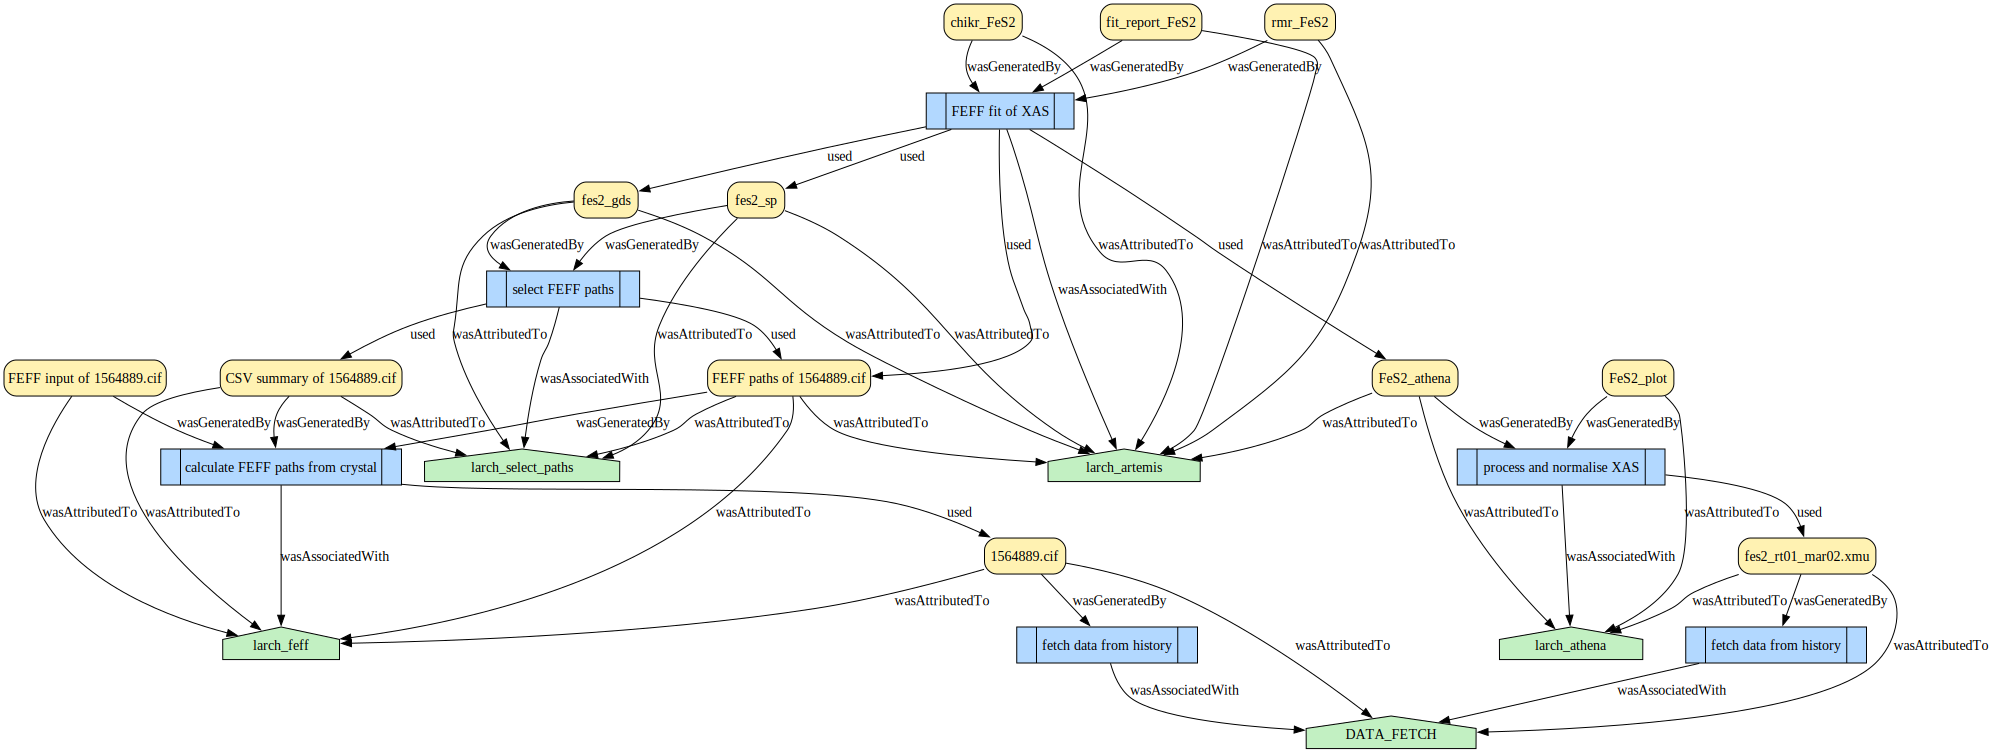

In [4]:
prov_dot = draw_prov_only(roc_graph)
prov_dot.render("prov_only_graph", format="png")
display(prov_dot)

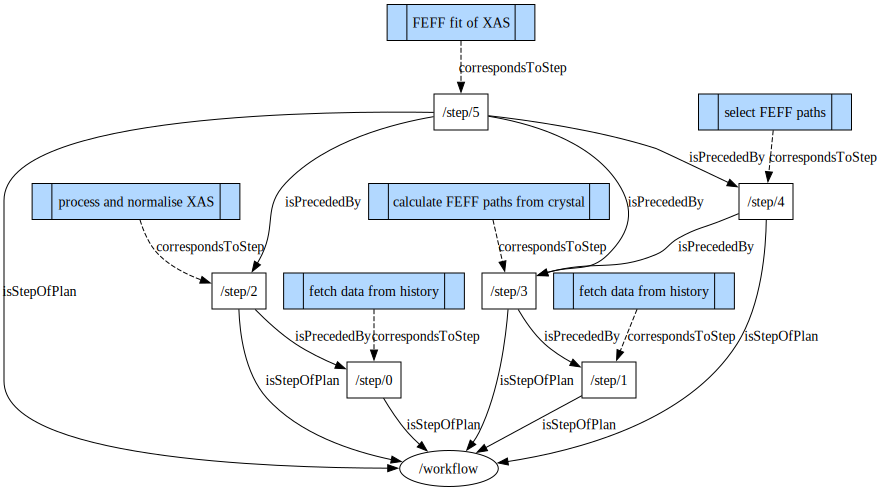

In [5]:
plan_dot = draw_pplan_only(roc_graph)
plan_dot.render("plan_only_graph", format="png")
display(plan_dot)

In [6]:
datasets_json = get_roc_json_part(file_path, "datasets_attrs.txt")
print(f"Dataset count: {len(datasets_json)}")
print("First Dataset:")
print(datasets_json[0]['name'])
datasets_json[0]

Dataset count: 12
First Dataset:
fes2_rt01_mar02.xmu


{'annotation': '',
 'blurb': '353 lines',
 'copied_from_history_dataset_association_id_chain': ['19a53e40e411a2fb'],
 'create_time': '2024-10-23 14:09:56.601127',
 'dataset_uuid': 'f640df2f-ce68-4309-bc83-2e052fb749f1',
 'deleted': False,
 'designation': None,
 'encoded_id': 'df0bac1ee137448a',
 'extension': 'txt',
 'file_metadata': {},
 'file_name': 'datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt',
 'hid': 1,
 'history_encoded_id': '35de17ca7ffc563a',
 'info': 'uploaded txt file',
 'metadata': {'data_lines': 353, 'dbkey': '?'},
 'model_class': 'HistoryDatasetAssociation',
 'name': 'fes2_rt01_mar02.xmu',
 'peek': '#%name: FeS2 powder  Room Temperature\n#%atom: FeS2\n#%edge: K\n#%xtal: FeS2.inp\n#%prep: powder on tape, 4 layers\n',
 'state': 'ok',
 'tags': [],
 'tool_version': None,
 'update_time': '2024-10-23 14:09:56.601131',
 'validated_state': 'unknown',
 'validated_state_message': None,
 'visible': True}

In [7]:
f_json = get_roc_json_part(file_path, "invocation_attrs.txt")
steps = f_json[0].get('steps')
print(f"Step Count {len(steps)}")
print("first step:")
steps[1]

Step Count 6
first step:


{'model_class': 'WorkflowInvocationStep',
 'state': 'scheduled',
 'create_time': '2024-10-23 14:09:56.831381',
 'update_time': '2024-10-23 14:09:56.831383',
 'order_index': 1,
 'action': None,
 'outputs': [{'output_name': 'output',
   'dataset': {'model_class': 'HistoryDatasetAssociation',
    'encoded_id': 'df02c7af9dfe5b62'}}],
 'output_collections': []}

In [8]:
jobs_json = get_roc_json_part(file_path, "jobs_attrs.txt")
print(f"Jobs Count: {len(jobs_json)}")
print("first job:")
print(jobs_json[0])
print(jobs_json[0]['output_dataset_mapping'])
the_mappings = jobs_json[0]['output_dataset_mapping']
base = "/"
for a_job in jobs_json: 
    job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
    for a_mapping in a_job['input_dataset_mapping']:
        for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
            ds_uri = URIRef(base + f"dataset/{a_ds_id}")
            print(job_uri, PROV.used, ds_uri)

Jobs Count: 6
first job:
{'command_line': "python '/srv/galaxy/server/data_fetch.py' --galaxy-root '/srv/galaxy/server' --datatypes-registry '/mnt/nfs/data/job_work_dir/004/4434/registry.xml' --request-version '1' --request '/mnt/nfs/data/job_work_dir/004/4434/configs/tmp26x0tc9m'", 'create_time': '2024-05-30T17:37:28.226523', 'encoded_id': 'c60463f2d425dc91', 'exit_code': None, 'galaxy_version': '23.2', 'implicit_output_dataset_collection_mapping': {}, 'info': None, 'input_dataset_collection_element_mapping': {}, 'input_dataset_collection_mapping': {}, 'input_dataset_mapping': {}, 'job_messages': [], 'job_stderr': None, 'job_stdout': None, 'model_class': 'Job', 'output_dataset_collection_mapping': {}, 'output_dataset_mapping': {'output0': ['19a53e40e411a2fb']}, 'params': {'file_count': '1', 'files': [{'__index__': 0, 'file_data': '/mnt/nfs/data/tus/33df1db0c5d9a37cbb86b5ad05b5b3a8'}], 'paramfile': None, 'request_json': '{"targets": [{"destination": {"type": "hdas"}, "elements": [{"nam

In [9]:
# correct association of sw agents to actions instead of steps
def redirect_software_agents(a_graph):
    #for s, p, o in a_graph.triples((None, RDF.type, PROV.SoftwareAgent)):
    #    for s1, p1, o1 in a_graph.triples((None, PROV.wasAssociatedWith, s)):
    #        for s2, p2, o2 in a_graph.triples((s1, RDF.type, PPLAN.Step)):
    #            print(f"{s} asscociated to step {s1}")
    #            for s3, p3, o3 in a_graph.triples((None, PPLAN.correspondsToStep, s1)):
    #                print(f"redirect to {s3}")
    #                a_graph.remove((s1, p1, o1))
    #                a_graph.add((s, PROV.wasAssociatedWith, s3))
                    
    #            for s4, p4, o4 in a_graph.triples((s3, PROV.used, None)):
    #                a_graph.add((o4, PROV.wasAttributedTo, s))
                    
    #            for s5, p5, o5 in a_graph.triples((None, PROV.wasGeneratedBy, s3)):
    #                a_graph.add((s5, PROV.wasAttributedTo, s))
    to_remove = set()
    to_add = set()
    
    for agent in a_graph.subjects(RDF.type, PROV.SoftwareAgent):
        for step in a_graph.subjects(PROV.wasAssociatedWith, agent):
            if (step, RDF.type, PPLAN.Step) not in a_graph:
                continue
    
            for concrete_step in a_graph.subjects(PPLAN.correspondsToStep, step):
                to_remove.add((step, PROV.wasAssociatedWith, agent))
                to_add.add((agent, PROV.wasAssociatedWith, concrete_step))
    
                for used in a_graph.objects(concrete_step, PROV.used):
                    to_add.add((used, PROV.wasAttributedTo, agent))
    
                for gen in a_graph.subjects(PROV.wasGeneratedBy, concrete_step):
                    to_add.add((gen, PROV.wasAttributedTo, agent))
    
    
    for triple in to_remove:
        a_graph.remove(triple)
    
    for triple in to_add:
        a_graph.add(triple)


# add custom labels to activities
def custom_labels(a_graph):
    print("try add custom labelling")
    for an_activity in a_graph.subjects(RDF.type, PROV.Activity):
        #print(f"Activity {an_activity}")
        for an_agent in a_graph.objects(an_activity, PROV.wasAssociatedWith):
            #print(f"Activity {an_activity} associated with {an_agent}")
            for agent_label in a_graph.objects(an_agent, RDFS.label):
                #print(f"Agent label: {agent_label}")
                d_label = str(agent_label)
                pref_label = ""
                if d_label == "larch_athena":
                    pref_label = "process and normalise XAS"
                elif d_label == "larch_artemis":
                    pref_label = "FEFF fit of XAS"
                elif d_label == "larch_select_paths":
                    pref_label = "select FEFF paths"
                elif d_label == "larch_feff":
                    pref_label = "calculate FEFF paths from crystal"
                elif d_label == "DATA_FETCH":
                    pref_label = "fetch data from history"
            if pref_label != "":
                a_graph.add((an_activity, SKOS.prefLabel, Literal(pref_label)))
                    
        

try add custom labelling


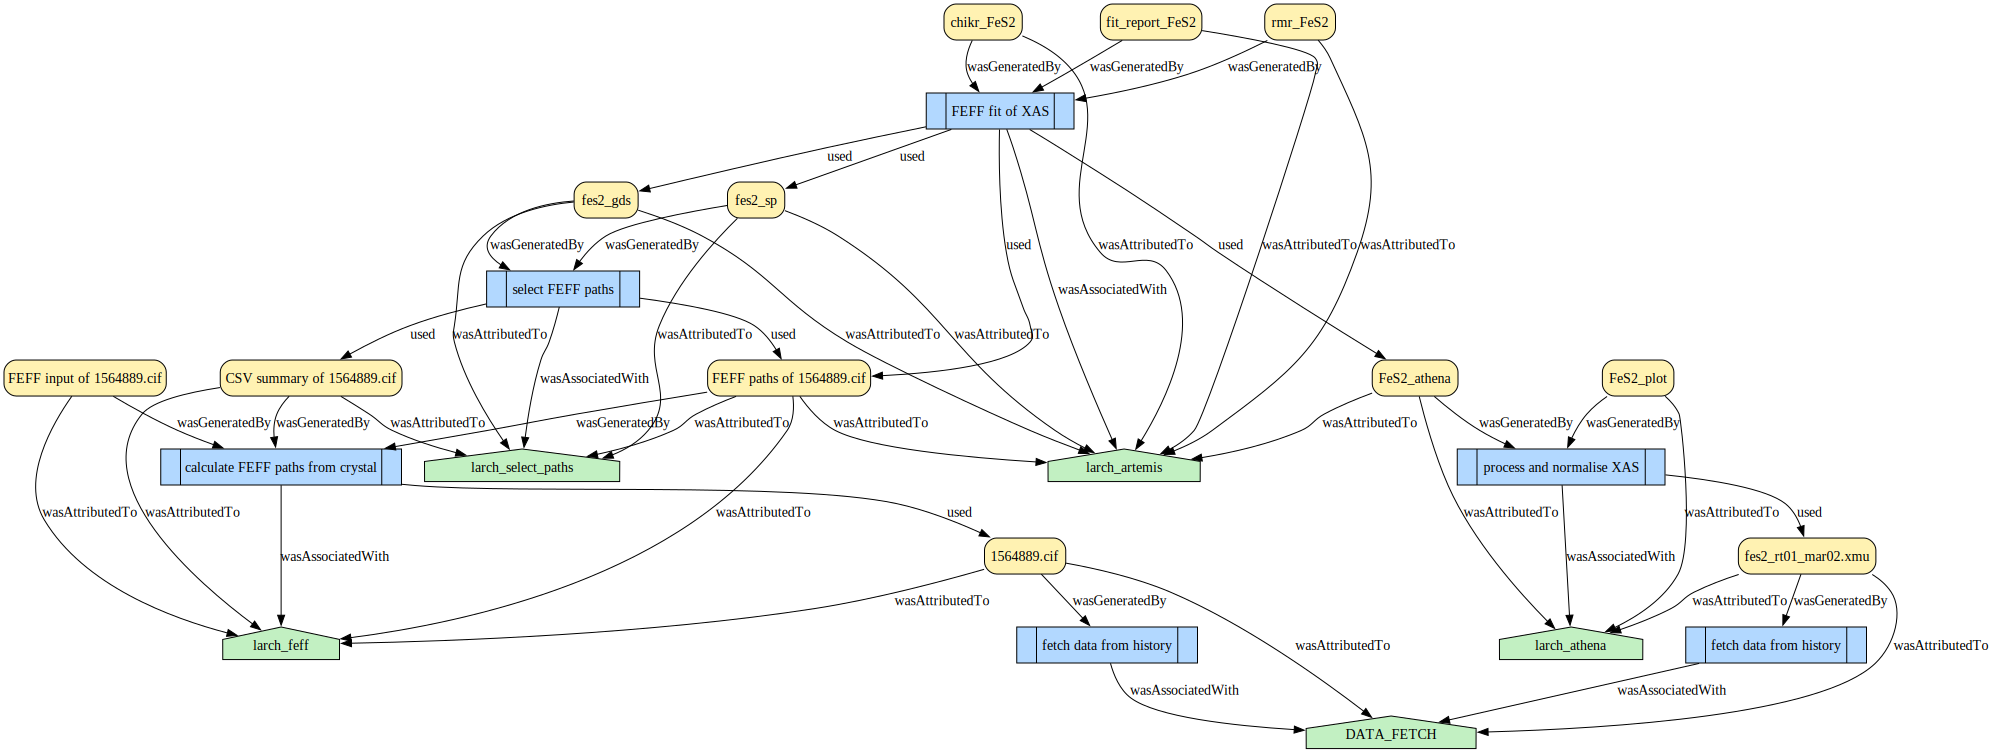

In [10]:
test_graph = copy.deepcopy(roc_graph)
custom_labels(test_graph)
prov_dot = draw_prov_only(test_graph)
prov_dot.render("prov_only_graph", format="png")
display(prov_dot)

In [31]:
import pandas as pd

qres = roc_graph.query("""
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX skos:   <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema:<https://schema.org/>

SELECT
  (COALESCE(?outPref, ?outName, ?outLabel, STR(?output)) AS ?dataset)
  (COALESCE(?actPref, ?actName, ?actLabel, STR(?activity)) AS ?activity)
  (COALESCE(?toolPref, ?toolName, ?toolLabel, STR(?tool)) AS ?tool)
  ?inputs
WHERE {
  ?output prov:wasGeneratedBy ?activity .

  # ---- output (dataset) labels ----
  OPTIONAL { ?output skos:prefLabel ?outPref . }
  OPTIONAL { ?output schema:name    ?outName . }
  OPTIONAL { ?output rdfs:label     ?outLabel . }

  # ---- activity labels ----
  OPTIONAL { ?activity skos:prefLabel ?actPref . }
  OPTIONAL { ?activity schema:name    ?actName . }
  OPTIONAL { ?activity rdfs:label     ?actLabel . }

  # ---- tool / agent ----
  OPTIONAL {
    ?activity prov:wasAssociatedWith ?tool .
    OPTIONAL { ?tool skos:prefLabel ?toolPref . }
    OPTIONAL { ?tool schema:name    ?toolName . }
    OPTIONAL { ?tool rdfs:label     ?toolLabel . }
  }

  # ---- inputs (aggregated, robust) ----
  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(
              DISTINCT COALESCE(?inPref, ?inName, ?inLabel, STR(?input));
              separator=", "
           ) AS ?inputs)
    WHERE {
      ?activity prov:used ?input .
      OPTIONAL { ?input skos:prefLabel ?inPref . }
      OPTIONAL { ?input schema:name    ?inName . }
      OPTIONAL { ?input rdfs:label     ?inLabel . }
    }
    GROUP BY ?activity
  }
}
ORDER BY ?dataset
""")

df = pd.DataFrame(
    [(str(a), str(t), str(o), str(i)) for o, a, t, i in qres],
    columns=["Activity", "Tool", "Dataset", "Inputs"]
)

In [32]:
df

,Activity,Tool,Dataset,Inputs
0,fetch data from history,DATA_FETCH,1564889.cif,None
1,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
2,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
3,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
4,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
5,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu
6,FEFF fit of XAS,larch_artemis,chikr_FeS2,"FeS2_athena, FEFF paths of 1564889.cif, fes2_g..."
7,select FEFF paths,larch_select_paths,fes2_gds,"CSV summary of 1564889.cif, FEFF paths of 1564..."
8,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
9,select FEFF paths,larch_select_paths,fes2_sp,"CSV summary of 1564889.cif, FEFF paths of 1564..."
